Target lengths from percentiles:
70th percentile → 11
75th percentile → 11
80th percentile → 12
85th percentile → 13
90th percentile → 15
92th percentile → 16
95th percentile → 17
97th percentile → 19
99th percentile → 24

Target length: 11
Mean padding: 10.00
Median padding: 10.0
Max padding: 10
Zero-padding captions: 0 / 25426

Target length: 11
Mean padding: 10.00
Median padding: 10.0
Max padding: 10
Zero-padding captions: 0 / 25426

Target length: 12
Mean padding: 11.00
Median padding: 11.0
Max padding: 11
Zero-padding captions: 0 / 25426

Target length: 13
Mean padding: 12.00
Median padding: 12.0
Max padding: 12
Zero-padding captions: 0 / 25426

Target length: 15
Mean padding: 14.00
Median padding: 14.0
Max padding: 14
Zero-padding captions: 0 / 25426

Target length: 16
Mean padding: 15.00
Median padding: 15.0
Max padding: 15
Zero-padding captions: 0 / 25426

Target length: 17
Mean padding: 16.00
Median padding: 16.0
Max padding: 16
Zero-padding captions: 0 / 25426

Target length:

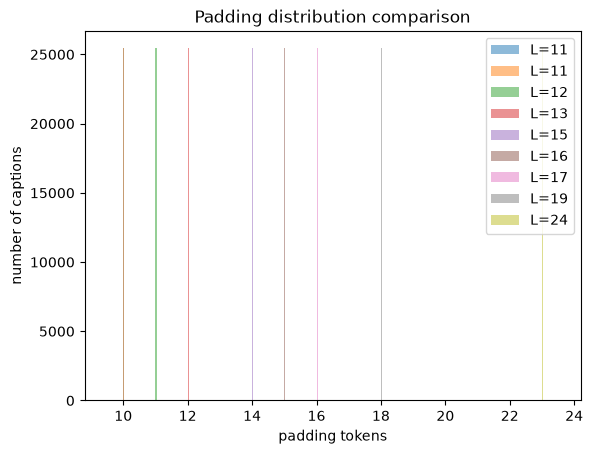

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# LOAD DATA
# =============================================================================

def load_captions_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


# =============================================================================
# LENGTH ANALYSIS
# =============================================================================

def get_lengths(captions):
    return np.array([len(c.split()) for c in captions])


def compute_max_len(captions, percentile: int = 97) -> int:
    lengths = [
        len(c.split())
        for caps in captions.values()
        for c in caps
    ]
    return int(np.percentile(lengths, percentile))


def compute_padding(lengths, target_len):
    return np.maximum(0, target_len - lengths)


def padding_stats(padding):
    return {
        "mean": padding.mean(),
        "median": np.median(padding),
        "max": padding.max(),
        "zero_ratio": (padding == 0).mean()
    }


def print_stats(L, stats, n):
    print(f"\nTarget length: {L}")
    print(f"Mean padding: {stats['mean']:.2f}")
    print(f"Median padding: {stats['median']}")
    print(f"Max padding: {stats['max']}")
    print(f"Zero-padding captions: {int(stats['zero_ratio'] * n)} / {n}")


def plot_padding(padding, label=None, alpha=1.0):
    plt.hist(padding, bins=30, alpha=alpha, label=label)


# =============================================================================
# MAIN COMPARISON
# =============================================================================

def compare_padding_distributions(captions, target_lens):
    lengths = get_lengths(captions)
    n = len(captions)

    plt.figure()

    for L in target_lens:
        padding = compute_padding(lengths, L)
        stats = padding_stats(padding)

        print_stats(L, stats, n)
        plot_padding(padding, label=f"L={L}", alpha=0.5)

    plt.title("Padding distribution comparison")
    plt.xlabel("padding tokens")
    plt.ylabel("number of captions")
    plt.legend()
    plt.show()


# =============================================================================
# USO
# =============================================================================

data = load_captions_json("../data/captions/captions_split_clean.json")

train_captions = data["train"]

# percentili da testare
percentiles = [70, 75, 80, 85, 90, 92, 95, 97, 99]

# converte percentili → lunghezze reali
target_lens = [
    compute_max_len(train_captions, p)
    for p in percentiles
]

print("Target lengths from percentiles:")
for p, L in zip(percentiles, target_lens):
    print(f"{p}th percentile → {L}")

padding = compute_padding(get_lengths(train_captions), target_lens[2])

#plot_padding(padding, label=f"L={target_lens[2]}")
#plt.legend()
#plt.show()

compare_padding_distributions(
    train_captions,
    target_lens=target_lens
)